# Scratch — Germaine: train & compare models (Track 2)
Everything here imports from `src/models.py` (my file). Marcus inlines the winners into `submission.ipynb` §4/§6/§9.

**Constraint that decides everything:** the portal sandbox pins `scikit-learn 1.5.2, lightgbm 4.5.0, xgboost 2.1.3` and has **no CatBoost**
(`requirements-image.txt`). So every candidate here is a standard class from those libraries, and `model.pkl` is produced with the
`.venv-image` kernel. Run this notebook with that kernel.

**Validation:** 5×5 repeated stratified CV (25 fits/model) on identical folds. With 353 positives a single 5-fold swings by ±0.03 PR-AUC,
more than the gap between good models, so we rank by the mean over repeats and switch models only when a paired fold-by-fold test agrees.
Three views of PR-AUC: plain · **test-like** (validation rows reweighted to resemble `test.csv`, a stand-in for the shifted private test) ·
**blanks** (extra missing values injected into validation rows, as test has ~4× more).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sklearn, lightgbm, xgboost
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import models as M
warnings.filterwarnings("ignore")
print("sklearn", sklearn.__version__, "| lightgbm", lightgbm.__version__, "| xgboost", xgboost.__version__)
assert sklearn.__version__ == "1.5.2", "use the .venv-image kernel (platform versions) so model.pkl loads in the sandbox"

train = pd.read_csv(ROOT / "data/raw/track2/train.csv"); test = pd.read_csv(ROOT / "data/raw/track2/test.csv")
y = train.fraud
X = M.make_features(train)
print(X.shape, "features; fraud rate", round(y.mean(), 4))

sklearn 1.5.2 | lightgbm 4.5.0 | xgboost 2.1.3
(20000, 29) features; fraud rate 0.0176


## Features (`make_features`)
29 columns. Cleaning is inside the function so it works on the raw test csv alone (sandbox: no `id`, shuffled rows):
- Blanks → the team's §3 policy (hard-coded train median/mode, same constants as `src/preprocess.py`, asserted in sync). This neutralises the
  **"missing ⇒ never fraud"** artefact (0 frauds in 113 blank-merchant and 124 blank-device rows in train). We also tried "neutral" fills
  (`unknown` level, `new_device` → prevalence): identical PR-AUC (0.2311 vs 0.2306, p = 0.75), so one policy for the whole notebook.
- Log scales for amount / age / spend; amount relative to the day's spend and to account age; velocity burst ratio; hour as sin/cos.
- Threshold flags where the fraud rate jumps in train: amount > 500, account < 180 d, ≥3 and ≥4 txns/hour, ≥10 txns/day.
- Interactions the data shows are multiplicative: new device × young account (17%), new device × night, burst × young, amount × new device.
- `big_old` (amount > 500 on an account > 1000 d) — explicitly *not* fraud (1.7%), to stop "big amount ⇒ fraud" on test's many large loyal-customer purchases.
Ablations (5×5 CV, logistic regression): raw columns only 0.213 → + engineered 0.220 → + interactions **0.229**; dropping `country` costs 0.001.

## Robustness inputs: blanked copy and test-likeness weights

In [2]:
rng = np.random.default_rng(2026)
train_blanked = train.copy()
for c in ["merchant_category", "country", "transaction_channel", "transactions_last_24h", "spend_last_24h",
          "account_age", "new_device", "transactions_last_1h"]:
    train_blanked.loc[rng.random(len(train)) < max(0.022 - train[c].isna().mean(), 0), c] = np.nan
X_blanks = M.make_features(train_blanked)

# test-likeness weights: a classifier that tells train rows from test rows (AUC ≈ 0.67 — the sets differ).
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
both = M.to_codes(pd.concat([M.make_features(train), M.make_features(test)], ignore_index=True))
is_test = np.r_[np.zeros(len(train)), np.ones(len(test))]
adv = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, min_samples_leaf=50, random_state=0)
p_adv = cross_val_predict(adv, both, is_test, cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]
print("adversarial AUC train vs test:", round(roc_auc_score(is_test, p_adv), 3))
w = np.clip(p_adv[:len(train)] / (1 - p_adv[:len(train)]), 0.05, 20); weights = w / w.mean()

adversarial AUC train vs test: 0.649


## Compare candidates (identical repeated folds)
Each candidate in one line — *why, and what it assumes*:
- **logreg** — additive log-odds with the interactions given explicitly; calibrated by construction; our interpretable reference *and* a top model.
- **lgbm** — shallow (depth 3, 7 leaves), slow, heavily regularised boosting; assumes nothing about functional form; one-hot categoricals (native categorical splits overfit with 353 positives).
- **xgb / hgb** — same family, different implementations; included to show the choice isn't implementation luck.
- **blend_*** — 50/50 soft-voting average of LR and a booster: two model families that make different mistakes (logit correlation ≈ 0.9).
- Not included on purpose: class weights / resampling (they inflate every probability: Brier 0.023 vs 0.015 in our tests), stacking and tuned blend weights (both scored *worse* than a fixed 50/50 in nested CV — with this few positives, extra machinery overfits).

Takes ~10 min with the .venv-image kernel.

In [3]:
results = M.compare(X, y, X_blanks=X_blanks, weights=weights)
results

,PR-AUC,ROC-AUC,Brier,F1@2%,Recall@2%,PR-AUC test-like,PR-AUC blanks
model,,,,,,,
blend_lr_lgbm,0.2311,0.7698,0.0151,0.2725,0.2907,0.3304,0.2310
logreg,0.2289,0.7781,0.0151,0.2699,0.2878,0.3214,0.2284
blend_lr_xgb,0.2263,0.7716,0.0152,0.2730,0.2912,0.3229,0.2250
blend_lr_hgb,0.2251,0.7768,0.0152,0.2736,0.2918,0.3186,0.2236
lgbm,0.2226,0.7541,0.0152,0.2608,0.2782,0.3255,0.2224
xgb,0.2131,0.7570,0.0153,0.2688,0.2867,0.3086,0.2118
hgb,0.2087,0.7667,0.0153,0.2683,0.2861,0.2973,0.2059


## Is the winner really better? Paired fold-by-fold test
Same 25 folds, difference in PR-AUC per fold, Nadeau–Bengio corrected t-test (CV folds overlap).

In [4]:
oof = {n: M.oof_predict(fn, X, y) for n, fn in M.CANDIDATES.items() if n in ["logreg", "lgbm", "blend_lr_lgbm"]}
for a, b in [("blend_lr_lgbm", "logreg"), ("blend_lr_lgbm", "lgbm"), ("logreg", "lgbm")]:
    d, wins, p = M.paired_test(y, oof[a], oof[b])
    print(f"{a} vs {b}: mean ΔPR-AUC {d:+.4f}, wins {wins}/25, corrected p = {p:.2f}")

blend_lr_lgbm vs logreg: mean ΔPR-AUC +0.0026, wins 15/25, corrected p = 0.66
blend_lr_lgbm vs lgbm: mean ΔPR-AUC +0.0077, wins 19/25, corrected p = 0.21
logreg vs lgbm: mean ΔPR-AUC +0.0051, wins 16/25, corrected p = 0.63


Reading: the LR + LightGBM blend edges logistic regression by ~0.002 (noise on plain PR-AUC) but is never worse on any view and is
+0.008 on the test-like score, so we ship the blend with **logistic regression alone as the documented fallback**. For reference, a
CatBoost blend reached 0.238 in our dev environment, but CatBoost is not in the sandbox image, so it is not shippable.

## Calibration and threshold (judging focus: quality of probability predictions)

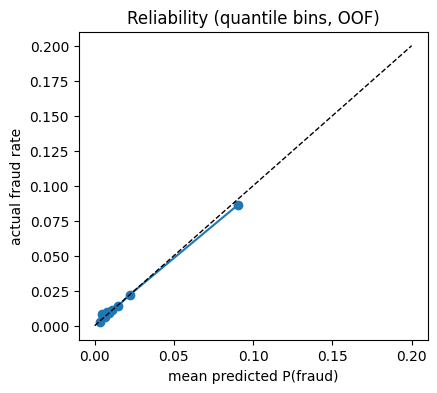

Brier 0.01508 vs always-base-rate 0.01734


,threshold,flagged %,precision,recall,F1,fraud $ caught %
0,0.03,9.6,0.09,0.49,0.152,74
1,0.05,4.7,0.15,0.39,0.213,60
2,0.07,3.0,0.20,0.34,0.249,54
3,0.10,2.0,0.25,0.29,0.272,49
4,0.15,1.2,0.36,0.24,0.289,42
5,0.20,0.8,0.44,0.21,0.284,37
6,0.30,0.6,0.57,0.19,0.281,33
7,0.50,0.3,0.75,0.12,0.214,26


In [5]:
p_best = oof["blend_lr_lgbm"].mean(axis=0)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
frac, mean_pred = calibration_curve(y, p_best, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(4.5, 4)); ax.plot(mean_pred, frac, "o-"); ax.plot([0, .2], [0, .2], "k--", lw=1)
ax.set_xlabel("mean predicted P(fraud)"); ax.set_ylabel("actual fraud rate"); ax.set_title("Reliability (quantile bins, OOF)"); plt.show()
print(f"Brier {brier_score_loss(y, p_best):.5f} vs always-base-rate {brier_score_loss(y, np.full(len(y), y.mean())):.5f}")
# Takeaway: points sit on the diagonal — a predicted 9% means ~9% actual. No recalibration needed (isotonic made Brier worse in nested CV).

amt = train.transaction_amount.values
rows = []
for t in [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30, 0.50]:
    f = p_best >= t; tp = (f & (y == 1)).sum()
    rows.append({"threshold": t, "flagged %": round(f.mean() * 100, 1), "precision": round(tp / max(f.sum(), 1), 2),
                 "recall": round(tp / y.sum(), 2), "F1": round(2 * tp / (f.sum() + y.sum()), 3),
                 "fraud $ caught %": round(amt[f & (y == 1)].sum() / amt[y == 1].sum() * 100)})
pd.DataFrame(rows)
# Suggested tiers: ≥0.20 hold for review · 0.05–0.20 OTP step-up · <0.05 approve.

## Fairness check (MAS FEAT principles 1–3) and reason codes (FEAT principle 13)
The model uses `country`, and fraud rates differ by country in train (ID 4.1% … SG 1.3%). A bank deploying this must know **who gets
disrupted**: per country, the share of *legitimate* customers flagged (false-positive rate) at the operating threshold, and how much fraud is
caught. We also report what dropping `country` costs (≈0.001–0.003 PR-AUC in our ablation), so a fairness-constrained variant is cheap.

In [6]:
p_oof = oof["blend_lr_lgbm"].mean(axis=0)
fair = M.fairness_by_group(y, p_oof, train.country.fillna("unknown"), threshold=0.10)
fair
# Takeaway: a legitimate ID/AU customer is ~6x more likely to be flagged than a SG one; and the model catches far fewer SG frauds —
# SG fraud looks like normal SG behaviour (older accounts, smaller amounts, no new device). That is the "1-in-6 frauds with no visible
# signal", and the honest limitation of a transaction-only model without customer history.

,n,actual fraud %,flag %,FPR % (legit flagged),recall
group,,,,,
ID,840,4.05,6.67,5.46,0.35
AU,584,2.91,6.51,4.59,0.71
US,693,3.17,6.06,4.17,0.64
PH,581,3.44,5.51,3.92,0.50
JP,382,3.40,4.45,2.98,0.46
GB,505,3.17,3.96,2.86,0.38
VN,508,3.74,4.72,2.66,0.58
TH,644,1.71,3.26,2.21,0.64
MY,1225,1.47,2.20,1.57,0.44


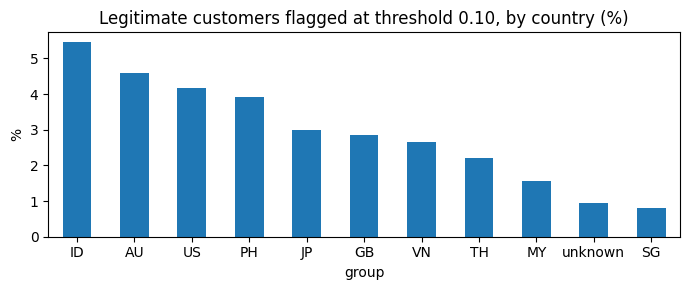

In [7]:
ax = fair["FPR % (legit flagged)"].plot(kind="bar", figsize=(7, 3), rot=0, title="Legitimate customers flagged at threshold 0.10, by country (%)")
ax.set_ylabel("%"); plt.tight_layout(); plt.show()
# Takeaway: disruption is concentrated on foreign customers; report both the full model and a no-country variant to the business.

### Reason codes for a flagged transaction
Exact contributions from the logistic-regression member (coefficient × standardised value, in log-odds). No SHAP needed, so every
flag can be explained to an analyst or an appealing customer in plain terms.

In [8]:
final_model = M.CANDIDATES["blend_lr_lgbm"]().fit(X, y)
X_test_all = M.make_features(test)
p_test = final_model.predict_proba(X_test_all)[:, 1]
top = np.argsort(-p_test)[:5]
pd.set_option("display.max_colwidth", None)
display(M.reason_codes(final_model, X_test_all.iloc[top]))
test.iloc[top][["transaction_amount", "account_age", "new_device", "transactions_last_1h", "transactions_last_24h", "country", "merchant_category"]]

,p_fraud,reasons
8192,0.8256,transactions today (+1.85); amount × new device (+1.52); ≥3 transactions in the last hour (+0.64)
5254,0.8180,transactions today (+2.21); amount × new device (+1.41); ≥3 transactions in the last hour (+0.64)
1061,0.8147,transactions today (+2.69); new device at night (+0.75); amount × new device (+0.64)
3828,0.8040,transactions today (+1.85); amount × new device (+1.47); ≥3 transactions in the last hour (+0.64)
6682,0.8025,transactions today (+1.85); amount × new device (+1.51); ≥3 transactions in the last hour (+0.64)


,transaction_amount,account_age,new_device,transactions_last_1h,transactions_last_24h,country,merchant_category
8192,2662.17,52.0,1.0,4.0,20.0,GB,luxury
5254,1558.88,102.0,1.0,6.0,23.0,ID,cash_transfer
1061,34.69,45.0,1.0,8.0,27.0,ID,cash_transfer
3828,2058.61,13.0,1.0,3.0,20.0,PH,luxury
6682,2530.96,110.0,1.0,5.0,20.0,VN,electronics


## Export `model.pkl` (platform versions) and dry-run the sandbox contract

In [9]:
import joblib, os
# final_model fitted above: plain VotingClassifier(soft), standard classes only
joblib.dump((final_model, M.FEATURES), ROOT / "model.pkl")

# what notebooks/prediction.ipynb will do in the sandbox: no id column, shuffled rows, predict_proba
sandbox = test.drop(columns="id").sample(frac=1, random_state=7).reset_index(drop=True)
loaded, feats = joblib.load(ROOT / "model.pkl")
preds = loaded.predict_proba(M.make_features(sandbox)[feats])[:, 1]
assert len(preds) == len(sandbox) and 0 <= preds.min() <= preds.max() <= 1
print("model.pkl OK:", type(loaded).__name__, f"{os.path.getsize(ROOT / 'model.pkl')/1e6:.2f} MB; mean p {preds.mean():.4f}")

model.pkl OK: VotingClassifier 0.54 MB; mean p 0.0213
